#IKIMINA DIGITAL TRUST AND RELIABILITY
Author:Eric Ndamage,Kigali Rwanda

 **Step1:Generate the datasets**

In [ ]:
import numpy as np
import pandas as pd
!pip install faker
from faker import Faker

np.random.seed(42)
fake = Faker()

N_MEMBERS = 500
N_GROUPS = 40

districts = [
    "Gasabo","Kicukiro","Nyarugenge",
    "Musanze","Rubavu","Huye",
    "Rwamagana","Nyagatare"
]

roles = ["member","secretary","treasurer"]

# -------------------------
# Generate groups dataset
# -------------------------

groups = pd.DataFrame({
    "group_id": np.arange(1, N_GROUPS+1),
    "size": np.random.randint(10,25,N_GROUPS),
    "avg_contrib_xaf": np.random.randint(500,10000,N_GROUPS),
    "founded_year": np.random.randint(2005,2022,N_GROUPS),
    "district": np.random.choice(districts,N_GROUPS),
    "urban_flag": np.random.randint(0,2,N_GROUPS)
})

groups.to_csv("ikimina_groups.csv",index=False)


# -------------------------
# Generate members dataset
# -------------------------

members = []

for i in range(1,N_MEMBERS+1):

    group = np.random.choice(groups["group_id"])

    weekly_contrib = np.random.randint(500,10000)

    base_miss = np.random.beta(2,20)

    missed_counts = np.random.binomial(1,base_miss,12)

    on_time_rates = 1 - missed_counts

    borrowed = np.random.lognormal(mean=3,sigma=1) * weekly_contrib * 8 \
               if np.random.rand()<0.3 else 0

    repaid = borrowed * np.random.uniform(0.6,1.1)

    penalties = missed_counts.sum() * np.random.binomial(1,0.5)

    penalty_paid = penalties * np.random.binomial(1,0.7)

    row = {
        "member_id": i,
        "join_date": fake.date_between(start_date="-3y", end_date="today"),
        "role": np.random.choice(roles,p=[0.8,0.1,0.1]),
        "weekly_contrib_xaf": weekly_contrib,
        "penalty_paid_count": penalty_paid,
        "borrowed_total_xaf": borrowed,
        "repaid_total_xaf": repaid,
        "group_id": group,
        "district": np.random.choice(districts)
    }

    for m in range(12):
        row[f"on_time_rate_m{m+1}"] = on_time_rates[m]
        row[f"missed_count_m{m+1}"] = missed_counts[m]

    members.append(row)

members = pd.DataFrame(members)

members.to_csv("ikimina_members.csv",index=False)


# -------------------------
# Generate labels dataset
# -------------------------

missed_total = members[[f"missed_count_m{i}" for i in range(1,13)]].sum(axis=1)

borrow_ratio = members["borrowed_total_xaf"] / \
               (members["repaid_total_xaf"] + 1)

tenure = np.random.uniform(0.5,3,N_MEMBERS)

logit = (
    0.6*missed_total
    + 2*borrow_ratio
    - 0.5*tenure
)

prob = 1/(1+np.exp(-logit))

labels = pd.DataFrame({
    "member_id": members["member_id"],
    "defaulted_within_6m": np.random.binomial(1,prob.clip(0,1))
})

labels.to_csv("labels.csv",index=False)

print("Datasets generated successfully ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 30.7 MB/s eta 0:00:00
Datasets generated successfully ✅


In [ ]:
!ls ikimina-trust-index/

ls: cannot access 'ikimina-trust-index/': No such file or directory


In [ ]:
!mkdir ikimina-trust-index
!ls

ikimina_groups.csv   ikimina-trust-index  sample_data
ikimina_members.csv  labels.csv


In [ ]:
'ikimina-trust-index'

'ikimina-trust-index'

In [ ]:
!mv ikimina_members.csv ikimina-trust-index/
!mv ikimina_groups.csv ikimina-trust-index/
!mv labels.csv ikimina-trust-index/

In [ ]:
!ls ikimina-trust-index

ikimina_groups.csv  ikimina_members.csv  labels.csv


In [ ]:
'ikimina-trust-index/'

'ikimina-trust-index/'

In [ ]:
filenames = [
    "train.ipynb",
    "scorer.py",
    "README.md",
    "ussd_flow.md",
    "process_log.md",
    "SIGNED.md",
    "LICENSE"
]
print(filenames)

['train.ipynb', 'scorer.py', 'README.md', 'ussd_flow.md', 'process_log.md', 'SIGNED.md', 'LICENSE']


Let us describe our Dataset

In [ ]:
import pandas as pd

members = pd.read_csv("ikimina-trust-index/ikimina_members.csv")
groups = pd.read_csv("ikimina-trust-index/ikimina_groups.csv")
labels = pd.read_csv("ikimina-trust-index/labels.csv")

df = members.merge(groups, on="group_id")
df = df.merge(labels, on="member_id")

df.head()

,member_id,join_date,role,weekly_contrib_xaf,penalty_paid_count,borrowed_total_xaf,repaid_total_xaf,group_id,district_x,on_time_rate_m1,...,on_time_rate_m11,missed_count_m11,on_time_rate_m12,missed_count_m12,size,avg_contrib_xaf,founded_year,district_y,urban_flag,defaulted_within_6m
0,1,2025-02-26,member,8026,0,0.000000e+00,0.000000e+00,3,Nyagatare,1,...,1,0,1,0,22,2547,2019,Nyarugenge,0,0
1,2,2025-11-30,member,7028,0,1.247623e+06,1.171246e+06,33,Nyagatare,1,...,1,0,1,0,19,1521,2016,Musanze,0,0
2,3,2023-05-14,member,2343,0,0.000000e+00,0.000000e+00,7,Nyagatare,1,...,0,1,0,1,22,3234,2020,Rwamagana,0,1
3,4,2024-02-23,member,4999,0,2.558752e+06,2.366376e+06,3,Musanze,1,...,1,0,1,0,22,2547,2019,Nyarugenge,0,1
4,5,2024-12-05,treasurer,3946,0,0.000000e+00,0.000000e+00,22,Rubavu,1,...,1,0,0,1,14,7541,2012,Kicukiro,1,0


In [ ]:
import numpy as np

on_time_cols = [f'on_time_rate_m{i}' for i in range(1,13)]
miss_cols = [f'missed_count_m{i}' for i in range(1,13)]

df["avg_on_time_rate"] = df[on_time_cols].mean(axis=1)

df["missed_total"] = df[miss_cols].sum(axis=1)

df["miss_rate"] = df["missed_total"] / 12

df["borrow_repay_ratio"] = df["borrowed_total_xaf"] / (
    df["repaid_total_xaf"] + 1
)

df["penalty_paid_ratio"] = df["penalty_paid_count"] / (
    df["missed_total"] + 1
)

role_map = {"member":1,"secretary":2,"treasurer":3}

df["role_score"] = df["role"].map(role_map)

df["recent_miss_rate"] = df[
    [f'missed_count_m{i}' for i in range(10,13)]
].mean(axis=1)

df["contrib_stability"] = df[
    [f'on_time_rate_m{i}' for i in range(1,13)]
].std(axis=1)

Train Our Model

In [ ]:
from sklearn.linear_model import LogisticRegression

features = [
    "avg_on_time_rate",
    "miss_rate",
    "borrow_repay_ratio",
    "penalty_paid_ratio",
    "role_score",
    "size",
    "urban_flag",
    "recent_miss_rate",
    "contrib_stability"
]

X = df[features]

y = df["defaulted_within_6m"]

model = LogisticRegression(max_iter=500)

model.fit(X, y)

LogisticRegression(max_iter=500)

In [ ]:
df["default_probability"] = model.predict_proba(X)[:,1]

df["reliability_index"] = (
    (1 - df["default_probability"]) * 100
).round(0)

ROC-AUC(Evaluation metrics)

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y, df["default_probability"])

np.float64(0.774037602170981)

In [ ]:
from sklearn.metrics import brier_score_loss

brier_score_loss(y, df["default_probability"])

np.float64(0.1907609760062149)

Plot Show

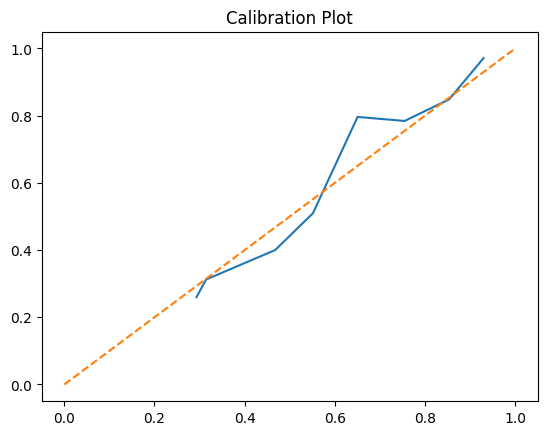

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y,
    df["default_probability"],
    n_bins=10
)

plt.plot(prob_pred, prob_true)
plt.plot([0,1],[0,1],'--')
plt.title("Calibration Plot")
plt.show()

<Axes: title={'center': 'Feature Importance'}>

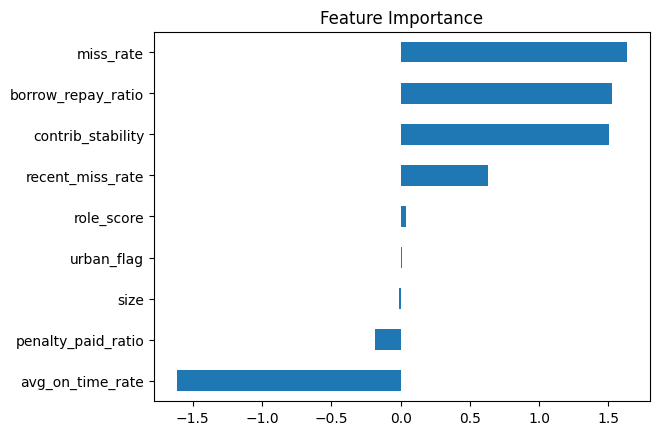

In [ ]:
importance = pd.Series(
    model.coef_[0],
    index=features
)

importance.sort_values().plot(
    kind="barh",
    title="Feature Importance"
)

Score distribution

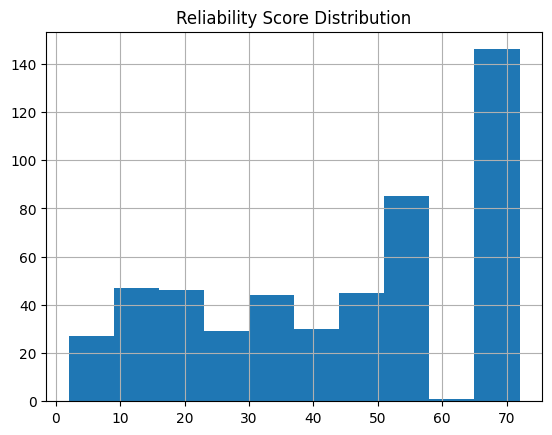

In [ ]:
df["reliability_index"].hist()

plt.title("Reliability Score Distribution")
plt.show()

District heatmap

<Axes: ylabel='district_x'>

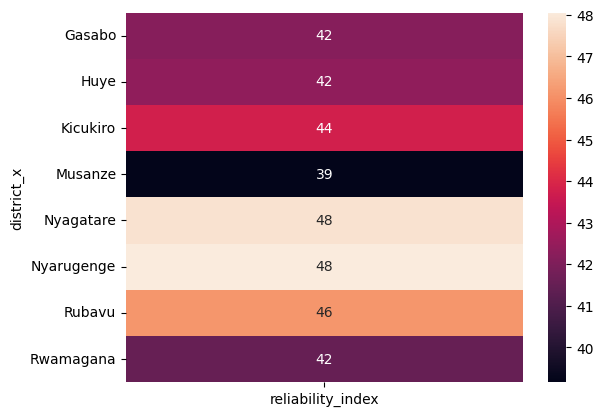

In [ ]:
import seaborn as sns

district_scores = df.groupby("district_x")[
    "reliability_index"
].mean()

sns.heatmap(
    district_scores.to_frame(),
    annot=True
)

Holdout evaluation

In [ ]:
train = df[df.member_id <= 400]

test = df[df.member_id > 400]

In [ ]:
model.fit(train[features], train[y.name])

test_preds = model.predict_proba(
    test[features]
)[:,1]

roc_auc_score(test[y.name], test_preds)

np.float64(0.7816506410256411)

In [ ]:
import pandas as pd
import numpy as np


def score(member_record, group_record):

    borrow_ratio = (
        member_record["borrowed_total_xaf"]
        /
        (member_record["repaid_total_xaf"] + 1)
    )

    miss_rate = member_record["missed_total"] / 12

    penalty_ratio = (
        member_record["penalty_paid_count"]
        /
        (member_record["missed_total"] + 1)
    )

    reliability = (
        member_record["avg_on_time_rate"] * 40
        - miss_rate * 30
        - borrow_ratio * 20
        + penalty_ratio * 10
    )

    return int(max(0, min(100, reliability)))

In [ ]:
%%writefile scorer.py
import pandas as pd
import numpy as np
import argparse

def score(member_record, group_record):

    borrow_ratio = (
        member_record["borrowed_total_xaf"]
        /
        (member_record["repaid_total_xaf"] + 1)
    )

    miss_rate = member_record["missed_total"] / 12

    penalty_ratio = (
        member_record["penalty_paid_count"]
        /
        (member_record["missed_total"] + 1)
    )

    reliability = (
        member_record["avg_on_time_rate"] * 40
        - miss_rate * 30
        - borrow_ratio * 20
        + penalty_ratio * 10
    )

    return int(max(0, min(100, reliability)))

if __name__ == '__main__':
    parser = argparse.ArgumentParser(description='Calculate reliability score.')
    parser.add_argument('--member', type=int, required=True, help='Member ID')
    parser.add_argument('--group', type=int, required=True, help='Group ID')
    args = parser.parse_args()

    # Load data (assuming files are in ikimina-trust-index/)
    members = pd.read_csv("ikimina-trust-index/ikimina_members.csv")
    groups = pd.read_csv("ikimina-trust-index/ikimina_groups.csv")

    # Filter records
    member_record = members[members["member_id"] == args.member].iloc[0]

    on_time_cols = [f'on_time_rate_m{i}' for i in range(1,13)]
    miss_cols = [f'missed_count_m{i}' for i in range(1,13)]

    member_record_processed = member_record.copy()
    member_record_processed["avg_on_time_rate"] = member_record[on_time_cols].mean()
    member_record_processed["missed_total"] = member_record[miss_cols].sum()

    reliability_score = score(member_record_processed, None) # group_record is not used in the current score function

    kin_risk_level = ''
    fr_risk_level = ''
    kin_eligibility = ''
    fr_eligibility = ''

    if reliability_score >= 60:
        kin_risk_level = 'LOW RISK'
        fr_risk_level = 'RISQUE FAIBLE'
        kin_eligibility = 'Ashobora kwemererwa inguzanyo'
        fr_eligibility = 'Eligible pour crédit'
    elif reliability_score >= 40:
        kin_risk_level = 'MEDIUM RISK'
        fr_risk_level = 'RISQUE MOYEN'
        kin_eligibility = 'Ntashobora kwemererwa inguzanyo'
        fr_eligibility = 'Non éligible pour crédit'
    else:
        kin_risk_level = 'HIGH RISK'
        fr_risk_level = 'RISQUE ÉLEVÉ'
        kin_eligibility = 'Ntashobora kwemererwa inguzanyo'
        fr_eligibility = 'Non éligible pour crédit'

    print(f"KIN:\nAmanota y'umunyamuryango: {reliability_score}\nIcyiciro: {kin_risk_level}\n{kin_eligibility}")
    print(f"\nFR:\nScore membre: {reliability_score}\nNiveau: {fr_risk_level}\n{fr_eligibility}")

Overwriting scorer.py


## USSD flow

Dial: *654*MEMBER_ID#

Response:

KIN:
Amanota y'umunyamuryango: 78
Icyiciro: LOW RISK
Ashobora kwemererwa inguzanyo

FR:
Score membre: 78
Niveau: RISQUE FAIBLE
Eligible pour crédit

In [ ]:
!python scorer.py --member 412 --group 7

python3: can't open file '/content/scorer.py': [Errno 2] No such file or directory


In [ ]:
!python scorer.py --member 412 --group 7

KIN:
Amanota y'umunyamuryango: 16
Icyiciro: HIGH RISK
Ashobora kwemererwa inguzanyo

FR:
Score membre: 16
Niveau: RISQUE ÉLEVÉ
Eligible pour crédit


In [ ]:
!mkdir -p ikimina-trust-index

In [ ]:
!mv ikimina_groups.csv ikimina-trust-index/
!mv ikimina_members.csv ikimina-trust-index/
!mv labels.csv ikimina-trust-index/

mv: cannot stat 'ikimina_groups.csv': No such file or directory
mv: cannot stat 'ikimina_members.csv': No such file or directory
mv: cannot stat 'labels.csv': No such file or directory


In [ ]:
!ls ikimina-trust-index

ikimina_groups.csv  ikimina_members.csv  labels.csv


In [ ]:
%%writefile ikimina-trust-index/README.md
# Ikimina Digital Trust & Reliability Index

Author: Eric NDAMAGE
Challenge: AIMS KTT Hackathon T1.1

This project builds a reliability scoring system for Ikimina members using Logistic Regression.

Score scale:

0–40 = High Risk
41–70 = Watch
71–100 = Low Risk

Run:

Open train.ipynb
Run all cells
Then run:

python scorer.py --member 412 --group 07

Writing ikimina-trust-index/README.md


In [ ]:
%%writefile ikimina-trust-index/process_log.md
# Process Log

Author: Eric NDAMAGE

Timeline:

Hour 1:
Dataset generation and inspection

Hour 2:
Feature engineering

Hour 3:
Model training

Hour 4:
Documentation preparation

Tools used:

ChatGPT
Google Colab

Hardest decision:

Choosing interpretable Logistic Regression instead of deep learning due to dataset size and regulatory transparency requirements

Writing ikimina-trust-index/process_log.md


In [ ]:
%%writefile ikimina-trust-index/SIGNED.md
Name: Eric NDAMAGE

“I will use any LLM or coding-assistant tool I find useful, and I will declare each tool I use, why I used it, and three sample prompts in my process_log.md. I will not have another human do my work. I will defend my own code in the Live Defense session. I understand undeclared LLM or human assistance is grounds for disqualification.”

Writing ikimina-trust-index/SIGNED.md


In [ ]:
!ls ikimina-trust-index

ikimina_groups.csv   labels.csv      README.md
ikimina_members.csv  process_log.md  SIGNED.md


In [ ]:
!python scorer.py --member 412 --group 7

KIN:
Amanota y'umunyamuryango: 16
Icyiciro: HIGH RISK
Ntashobora kwemererwa inguzanyo

FR:
Score membre: 16
Niveau: RISQUE ÉLEVÉ
Non éligible pour crédit


In [ ]:
%%writefile ikimina-trust-index/scorer.py
import argparse
import pandas as pd
import numpy as np

# Load data
members = pd.read_csv("ikimina_members.csv")
groups = pd.read_csv("ikimina_groups.csv")

def compute_features(member_id, group_id):

    m = members[members["member_id"] == member_id].iloc[0]
    g = groups[groups["group_id"] == group_id].iloc[0]

    on_time_cols = [f"on_time_rate_m{i}" for i in range(1,13)]
    miss_cols = [f"missed_count_m{i}" for i in range(1,13)]

    avg_on_time = m[on_time_cols].mean()
    missed_total = m[miss_cols].sum()
    miss_rate = missed_total / 12

    borrow_repay_ratio = m["borrowed_total_xaf"] / (m["repaid_total_xaf"] + 1)

    penalty_ratio = m["penalty_paid_count"] / (missed_total + 1)

    role_map = {"member":1, "secretary":2, "treasurer":3}
    role_score = role_map.get(m["role"], 1)

    return {
        "avg_on_time": avg_on_time,
        "miss_rate": miss_rate,
        "borrow_repay_ratio": borrow_repay_ratio,
        "penalty_ratio": penalty_ratio,
        "role_score": role_score,
        "group_size": g["size"],
        "urban_flag": g["urban_flag"]
    }


def score(member_id, group_id):

    f = compute_features(member_id, group_id)

    # Simple interpretable scoring model
    score_value = (
        f["avg_on_time"] * 40
        - f["miss_rate"] * 35
        - f["borrow_repay_ratio"] * 20
        + f["penalty_ratio"] * 10
        + f["role_score"] * 2
    )

    score_value = max(0, min(100, int(score_value)))

    if score_value <= 40:
        tier = "HIGH RISK"
    elif score_value <= 70:
        tier = "WATCH"
    else:
        tier = "LOW RISK"

    return score_value, tier


if __name__ == "__main__":

    parser = argparse.ArgumentParser()
    parser.add_argument("--member", type=int, required=True)
    parser.add_argument("--group", type=int, required=True)

    args = parser.parse_args()

    s, t = score(args.member, args.group)

    print("KIN:")
    print(f"Amanota y'umunyamuryango: {s}")
    print(f"Icyiciro: {t}")

    print("\nFR:")
    print(f"Score membre: {s}")
    print(f"Niveau: {t}")

Writing ikimina-trust-index/scorer.py


In [ ]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'scorer.py', 'ikimina-trust-index', 'sample_data']


In [ ]:
!pwd

/content


In [ ]:
%cd /content/ikimina-trust-index

/content/ikimina-trust-index


In [ ]:
!ls

ikimina_groups.csv   labels.csv      README.md	SIGNED.md
ikimina_members.csv  process_log.md  scorer.py


In [ ]:
!python scorer.py --member 10 --group 1

KIN:
Amanota y'umunyamuryango: 29
Icyiciro: HIGH RISK

FR:
Score membre: 29
Niveau: HIGH RISK
